In [49]:
from sklearn.model_selection import train_test_split

# **Machine learning Implementation**

In [50]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.33, random_state=42)

In [51]:
X_train.shape

(4718, 30)

In [52]:
Y_train.shape

(4718,)

In [53]:
from sklearn.ensemble import RandomForestClassifier

In [54]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)

In [55]:
rf_model.fit(X_train,Y_train)

RandomForestClassifier(random_state=42)

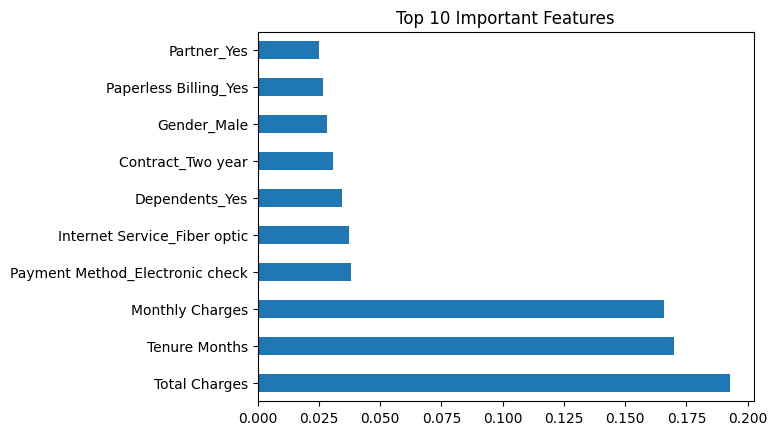

In [56]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Important Features')
plt.show()

In [57]:
y_pred=rf_model.predict(X_test)

In [58]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [59]:
from sklearn.metrics import accuracy_score

In [60]:
accuracy=accuracy_score(Y_test,y_pred)
print(accuracy)

0.7944086021505377


In [61]:
from sklearn.metrics import confusion_matrix

In [62]:
cm=confusion_matrix(Y_test,y_pred)


In [63]:
print(cm)

[[1507  177]
 [ 301  340]]


In [64]:
from sklearn.metrics import classification_report

In [65]:
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1684
           1       0.66      0.53      0.59       641

    accuracy                           0.79      2325
   macro avg       0.75      0.71      0.73      2325
weighted avg       0.79      0.79      0.79      2325



# **Approach 1 - Handle Class Imbalance**

In [66]:
rf_balanced=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
rf_balanced.fit(X_train,Y_train)
y_pred_balanced=rf_balanced.predict(X_test)
accuracy_balanced=accuracy_score(Y_test,y_pred_balanced)
cm_balanced=confusion_matrix(Y_test,y_pred_balanced)
print(accuracy_balanced,cm_balanced)
print(classification_report(Y_test,y_pred_balanced))

0.792258064516129 [[1517  167]
 [ 316  325]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1684
           1       0.66      0.51      0.57       641

    accuracy                           0.79      2325
   macro avg       0.74      0.70      0.72      2325
weighted avg       0.78      0.79      0.78      2325



# **Approach 2 - Hyperparameter tuning**

In [67]:
rf_tuned=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
rf_tuned.fit(X_train,Y_train)
y_pred_tuned=rf_tuned.predict(X_test)

print(classification_report(Y_test,y_pred_balanced))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1684
           1       0.66      0.51      0.57       641

    accuracy                           0.79      2325
   macro avg       0.74      0.70      0.72      2325
weighted avg       0.78      0.79      0.78      2325



# **Approach 3 - Feature Important Analysis**

In [68]:
import pandas as pd
feature_importance=pd.DataFrame({'Features':X.columns,'Importance':rf_tuned.feature_importances_})
feature_importance=feature_importance.sort_values(by='Importance',ascending=False)
print(feature_importance)

                                  Features  Importance
2                            Total Charges    0.174936
0                            Tenure Months    0.168788
1                          Monthly Charges    0.149540
25                       Contract_Two year    0.055201
6                           Dependents_Yes    0.046163
10            Internet Service_Fiber optic    0.041164
28         Payment Method_Electronic check    0.036818
24                       Contract_One year    0.027382
26                   Paperless Billing_Yes    0.025108
3                              Gender_Male    0.024296
13                     Online Security_Yes    0.023933
5                              Partner_Yes    0.023662
19                        Tech Support_Yes    0.020599
15                       Online Backup_Yes    0.019154
9                       Multiple Lines_Yes    0.017321
4                       Senior Citizen_Yes    0.017187
23                    Streaming Movies_Yes    0.016765
17        

In [69]:
print(feature_importance.tail(15))

                                  Features  Importance
4                       Senior Citizen_Yes    0.017187
23                    Streaming Movies_Yes    0.016765
17                   Device Protection_Yes    0.016257
21                        Streaming TV_Yes    0.016124
27  Payment Method_Credit card (automatic)    0.013924
29             Payment Method_Mailed check    0.011918
12     Online Security_No internet service    0.010496
16   Device Protection_No internet service    0.008300
11                     Internet Service_No    0.006247
18        Tech Support_No internet service    0.006218
20        Streaming TV_No internet service    0.005555
22    Streaming Movies_No internet service    0.004837
7                        Phone Service_Yes    0.004519
14       Online Backup_No internet service    0.003810
8          Multiple Lines_No phone service    0.003782


In [70]:
X_selected=X.drop(['Phone Service_Yes','Multiple Lines_No phone service'],axis=1)

In [71]:
X_train_sel, X_test_sel, Y_train_sel, Y_test_sel = train_test_split(
    X_selected, Y, test_size=0.2, random_state=42)

In [72]:
rf_selected=RandomForestClassifier(n_estimators=300,random_state=42,max_depth=10,class_weight='balanced')
rf_selected.fit(X_train_sel,Y_train_sel)
y_pred_selected=rf_selected.predict(X_test_sel)
print(classification_report(Y_test_sel,y_pred_selected))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.78      0.79      1409



# **Approach - Combination of trees and depth**

In [73]:

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.ensemble import RandomForestClassifier
n_estimators_list=[100,200,300,400,500]
max_depth_list=[5,10,15,20]
results=[]

# Re-split X and Y to ensure X_train and Y_train have consistent sample sizes
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=42)

for n_trees in n_estimators_list:
  for depth in max_depth_list:
    rf=RandomForestClassifier(n_estimators=n_trees,random_state=42,max_depth=depth,class_weight='balanced')
    rf.fit(X_train,Y_train)
    y_pred=rf.predict(X_test)
    accuracy=accuracy_score(Y_test,y_pred)
    recall=recall_score(Y_test,y_pred)
    precision=precision_score(Y_test,y_pred)
    f1=f1_score(Y_test,y_pred)
    results.append({'Trees':n_trees,'Depth':depth,'Accuracy':accuracy,'Recall':recall,'Precision':precision,'F1':f1})

result_df=pd.DataFrame(results)
result_df=result_df.sort_values(by=['Recall','Accuracy'],ascending=False)
print(result_df.head(20))

    Trees  Depth  Accuracy    Recall  Precision        F1
8     300      5  0.752258  0.822153   0.532861  0.646626
16    500      5  0.751398  0.820593   0.531850  0.645399
12    400      5  0.750968  0.820593   0.531313  0.645003
4     200      5  0.753118  0.815913   0.534219  0.645679
0     100      5  0.750968  0.808112   0.531828  0.641486
17    500     10  0.781935  0.751950   0.580723  0.655337
13    400     10  0.783226  0.750390   0.583030  0.656207
9     300     10  0.781935  0.748830   0.581114  0.654397
1     100     10  0.781505  0.748830   0.580411  0.653951
5     200     10  0.783226  0.745710   0.583639  0.654795
14    400     15  0.798710  0.619345   0.639291  0.629160
18    500     15  0.796989  0.617785   0.635634  0.626582
10    300     15  0.795699  0.613105   0.633871  0.623315
2     100     15  0.793548  0.603744   0.631321  0.617225
6     200     15  0.796559  0.602184   0.639073  0.620080
19    500     20  0.796989  0.535101   0.663443  0.592401
15    400     

In [74]:
from sklearn.model_selection import cross_val_score
final_rf=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')

In [75]:
cv_accuracy=cross_val_score(final_rf,X,Y,cv=5,scoring='accuracy')
print(cv_accuracy)

[0.78637331 0.8012775  0.77430802 0.79474432 0.80042614]


In [76]:
cv_accuracy.mean()

np.float64(0.7914258581198788)

In [77]:
cv_recall=cross_val_score(final_rf,X,Y,cv=5,scoring='recall')
print(cv_recall)

[0.44117647 0.5        0.47058824 0.48395722 0.52010724]


In [78]:
cv_recall.mean()

np.float64(0.4831658327479175)

# **With AUC & ROC Curve**

In [79]:
from sklearn.metrics import roc_auc_score,roc_curve

In [80]:
import matplotlib.pyplot as plt

In [81]:
y_prob=rf_tuned.predict_proba(X)

In [82]:
y_prob1=rf_tuned.predict_proba(X_test)

In [83]:
churn_prob=y_prob[:,1]

In [84]:
churn_prob=y_prob1[:,1]

In [85]:

fpr,tpr,threshold=roc_curve(Y_test,churn_prob)
auc_score=roc_auc_score(Y_test,churn_prob)
print(auc_score)

0.8368238648785857


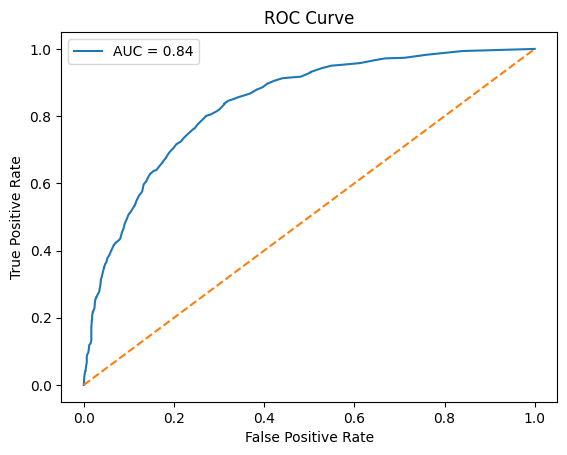

In [86]:
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()